In [15]:
import pandas as pd

In [16]:
import numpy as np

In [17]:
import matplotlib.pyplot as plt

In [18]:
import seaborn as sns

In [19]:
%matplotlib inline

In [20]:
df = pd.read_csv("C:\Users\nimes\Jupyter Notebook\Video_Game_Sales_Predictor\data\external\1. Cleaning & Missing Values")

In [21]:
df.head()

,Game Title,Console,Genre,Publisher,Developer,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.40000,20.33,6.37,0.99,9.85,3.12,2013
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.70000,19.39,6.06,0.60,9.71,3.02,2014
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.60000,16.15,8.41,0.47,5.49,1.78,2002
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,7.10189,15.87,9.06,0.06,5.33,1.42,2013
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.10000,15.09,6.18,0.41,6.05,2.44,2015


In [22]:
df.count()

Game Title              18919
Console                 18919
Genre                   18919
Publisher               18919
Developer               18919
Critic Score            18919
Sales                   18919
North American Sales    18919
Japanese Sales          18919
EU Sales                18919
Other Sales             18919
Release Year            18919
dtype: int64

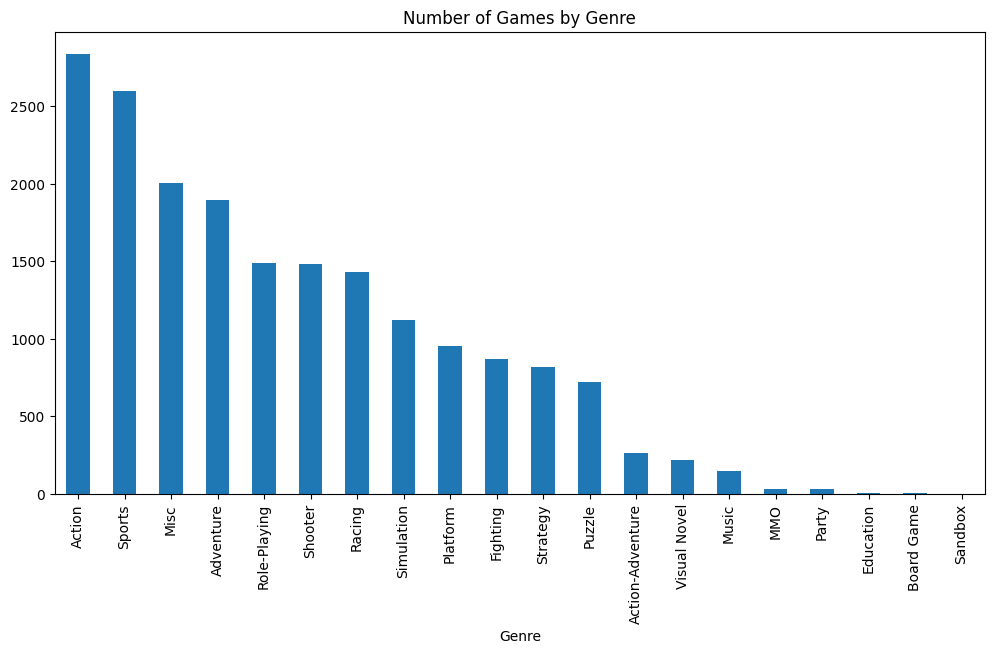

In [23]:
# Genre counts

df["Genre"].value_counts().plot(kind="bar", figsize=(12,6))
plt.title("Number of Games by Genre")
plt.show()

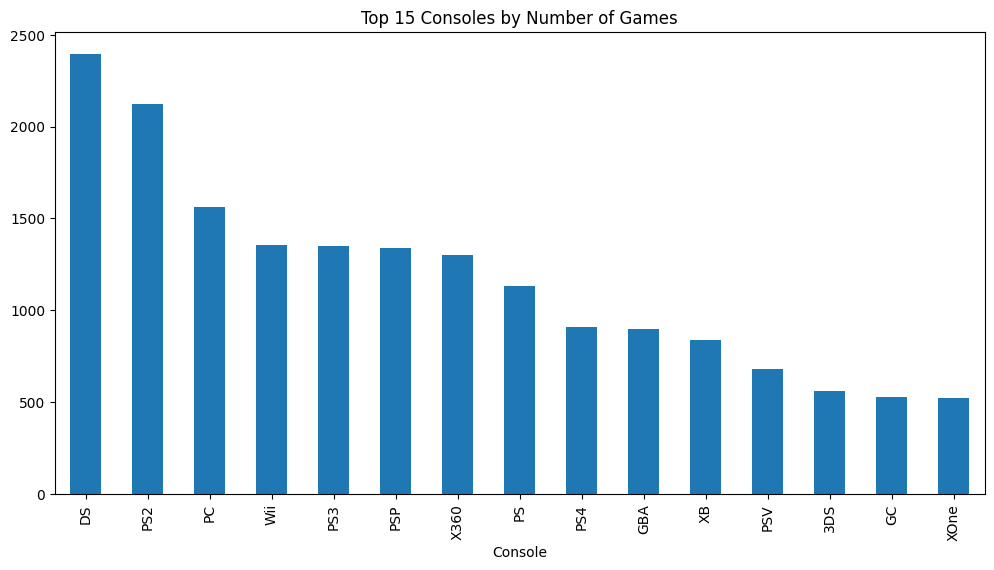

In [24]:
# Top 15 Consoles by Sales

df["Console"].value_counts().head(15).plot(kind="bar", figsize=(12,6))
plt.title("Top 15 Consoles by Number of Games")
plt.show()

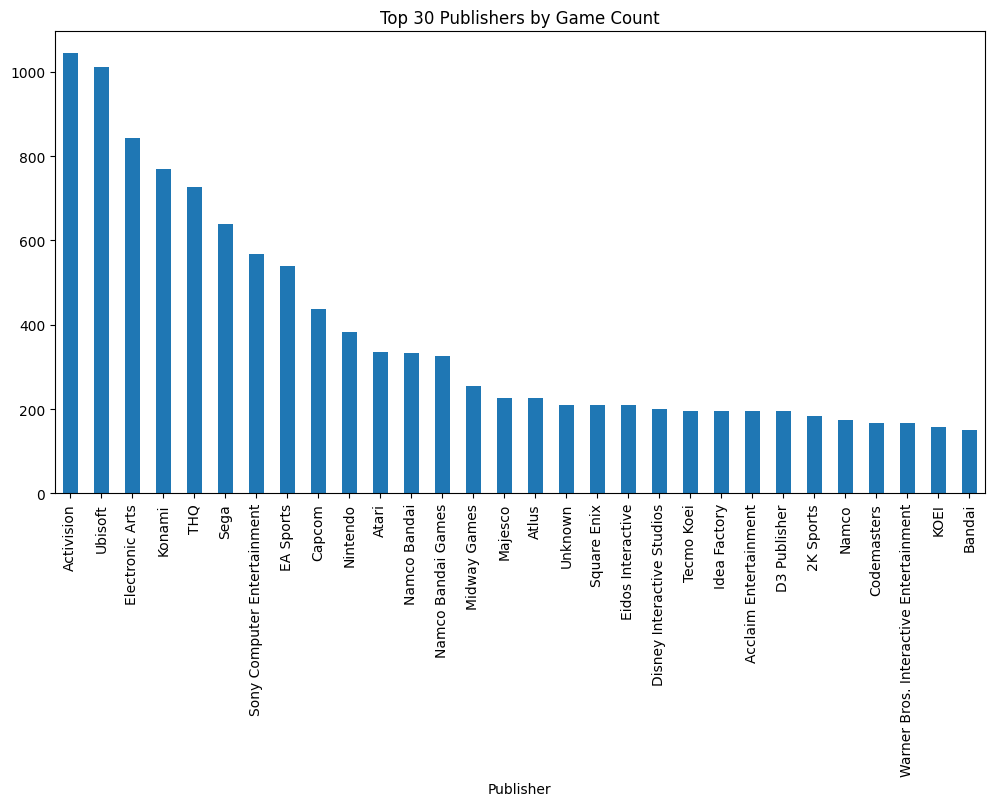

In [25]:
# Top 30 Publishers 

df["Publisher"].value_counts().head(30).plot(kind="bar", figsize=(12,6))
plt.title("Top 30 Publishers by Game Count")
plt.show()

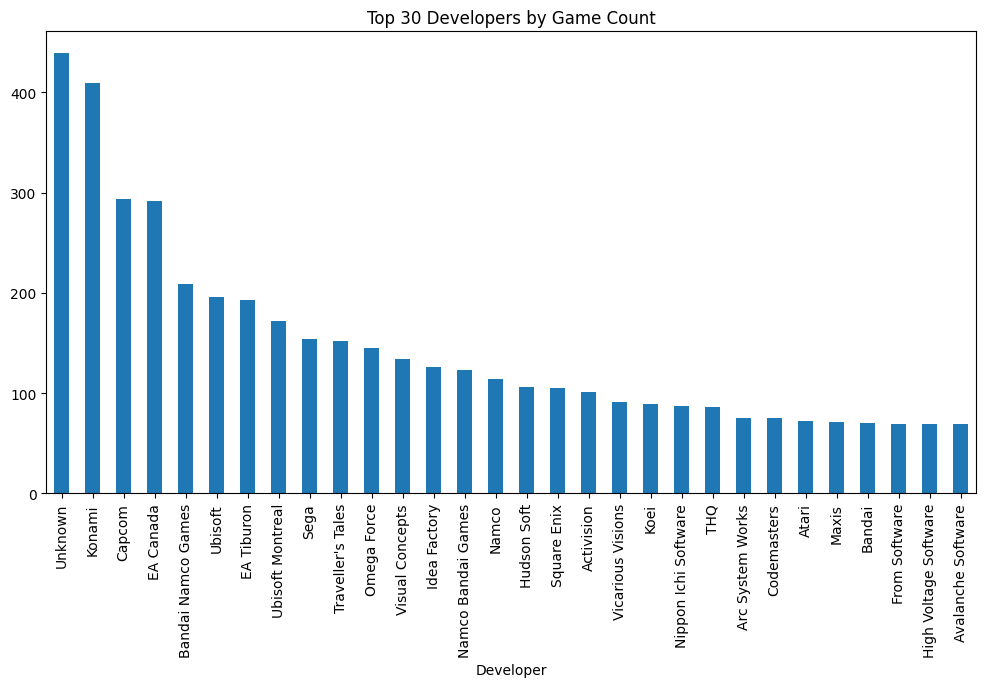

In [26]:
# Top 30 Developers 

df["Developer"].value_counts().head(30).plot(kind="bar", figsize=(12,6))
plt.title("Top 30 Developers by Game Count")
plt.show()

In [27]:
# Frequency encoding for Publisher & Developer
df["Publisher Freq"] = df["Publisher"].map(df["Publisher"].value_counts())
df["Developer Freq"] = df["Developer"].map(df["Developer"].value_counts())
df["Console Freq"] = df["Console"].map(df["Console"].value_counts())
df["Genre Freq"] = df["Genre"].map(df["Genre"].value_counts())

In [28]:
df.head()

,Game Title,Console,Genre,Publisher,Developer,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year,Publisher Freq,Developer Freq,Console Freq,Genre Freq
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.40000,20.33,6.37,0.99,9.85,3.12,2013,93,22,1348,2839
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.70000,19.39,6.06,0.60,9.71,3.02,2014,93,22,908,2839
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.60000,16.15,8.41,0.47,5.49,1.78,2002,93,22,2125,2839
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,7.10189,15.87,9.06,0.06,5.33,1.42,2013,93,22,1302,2839
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.10000,15.09,6.18,0.41,6.05,2.44,2015,1044,56,908,1485


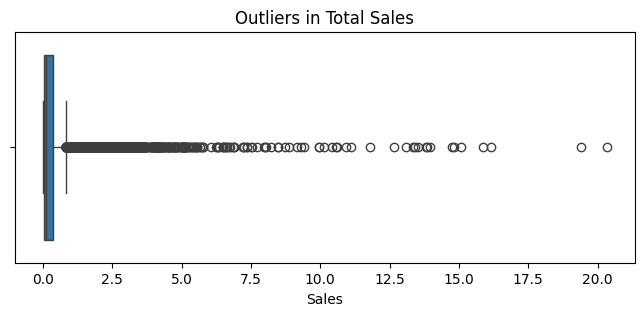

In [29]:
# Outliers for Total Sales 

plt.figure(figsize=(8,3))
sns.boxplot(x=df['Sales'])
plt.title("Outliers in Total Sales")
plt.show()

In [1]:
# 1) Compute IQR and bounds
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Sales can't be negative; use 0 as the practical minimum
lower_cutoff = max(0, lower_bound)

print(f"Q1={Q1:.3f}, Q3={Q3:.3f}, IQR={IQR:.3f}")
print(f"Lower bound (IQR)={lower_bound:.3f} → using cutoff={lower_cutoff:.3f}")
print(f"Upper bound (IQR)={upper_bound:.3f}")

# 2) Detect outliers
lower_outliers = df["Sales"] < lower_cutoff
upper_outliers = df["Sales"] > upper_bound

print("Lower-bound outliers:", lower_outliers.sum())
print("Upper-bound outliers (kept):", upper_outliers.sum())

# 3) Remove ONLY lower-bound outliers
df = df[~lower_outliers].copy() 
df = df[df["Sales"] > 0].copy()

NameError: name 'df' is not defined

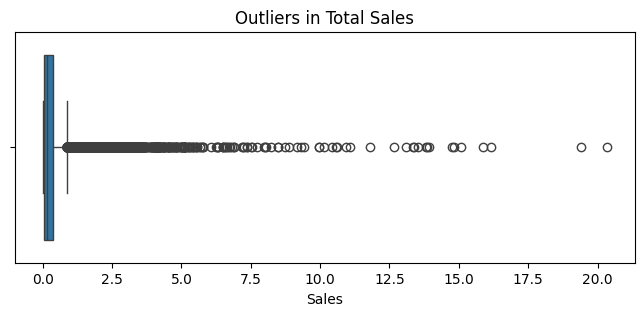

In [31]:
# Outliers for Total Sales 

plt.figure(figsize=(8,3))
sns.boxplot(x=df['Sales'])
plt.title("Outliers in Total Sales")
plt.show()

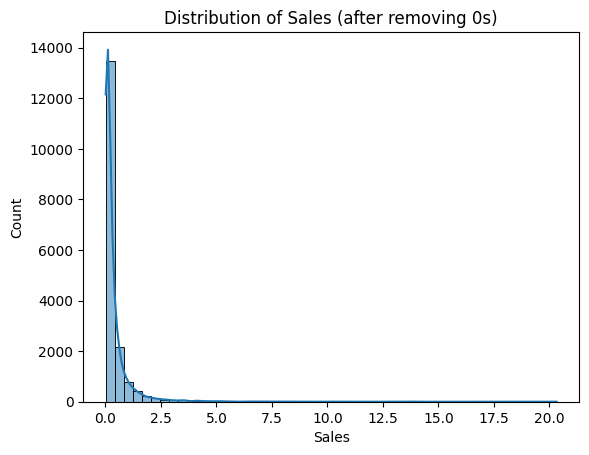

In [32]:
# Histogram for Sales Ater Outlier removal

sns.histplot(df["Sales"], bins=50, kde=True)
plt.title("Distribution of Sales (after removing 0s)")
plt.show()

In [35]:
df = df.drop(['Publisher','Genre','Console','Developer'], axis=1) # remove columns

In [36]:
df.to_csv("C:\Users\nimes\Jupyter Notebook\Video_Game_Sales_Predictor\data\external\2. Encoding\Frequency Encoding", index=False)